# **Lab 3: Polynomial Regression**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# checking for nulls, just for safety.

df = pd.read_csv("data/noisy_2.txt", sep=" ", header=None, names=["x", "y"])
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       10000 non-null  float64
 1   y       10000 non-null  float64
dtypes: float64(2)
memory usage: 156.4 KB


In [3]:
# loading the data into a numpy array

data = np.loadtxt("data/noisy_2.txt", delimiter=" ")
data.shape

(10000, 2)

In [4]:
# intializing the feature and target variables

x = data[:, 0]
y = data[:, 1]

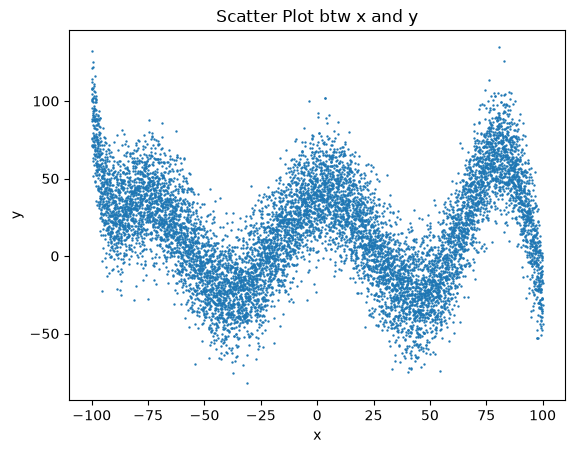

In [5]:
# examining the relationship between the feature and the target variable

plt.scatter(x, y, s=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Plot btw x and y")
plt.show()

**Note :** The relationship between input feature and the target variable is *non-linear*

In [6]:
# intializing the seed for reproducibility, as we are gonna shuffle the data.

np.random.seed(42)

indices = np.random.permutation(len(x))

x_shuffled = x[indices]
y_shuffled = y[indices]

In [7]:
# splitting the data into train, validation and test sets.

train_end = int(0.6 * len(x))   # 60% for training
val_end = int(0.8 * len(x))     # 20% for validation and remaining for testing

x_train = x_shuffled[:train_end]
y_train = y_shuffled[:train_end]

x_val = x_shuffled[train_end:val_end]
y_val = y_shuffled[train_end:val_end]

x_test = x_shuffled[val_end:]
y_test = y_shuffled[val_end:]

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(6000,) (6000,)
(2000,) (2000,)
(2000,) (2000,)


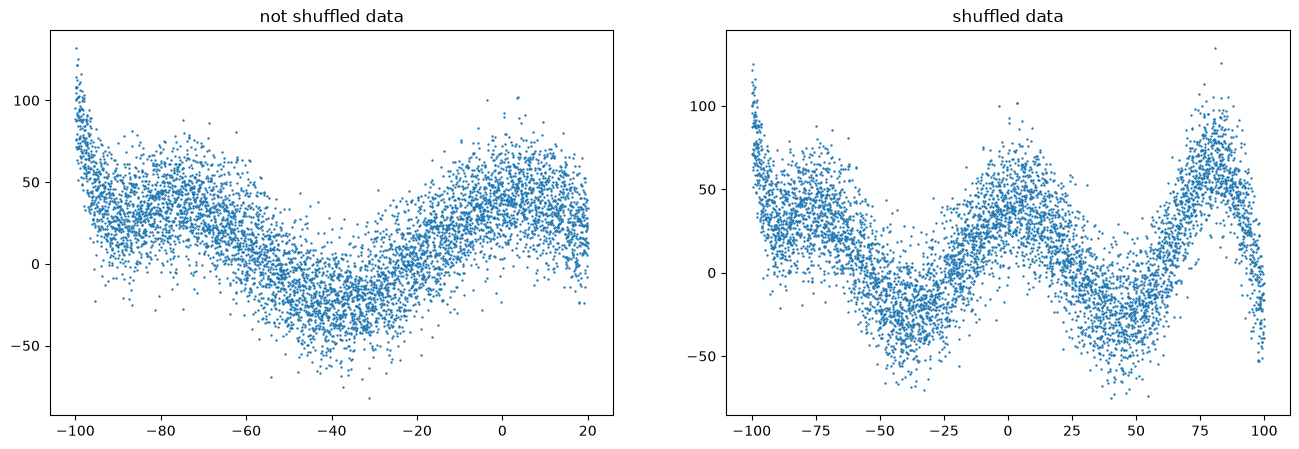

In [8]:
# just curious on how the data looks like before and after shuffling.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.scatter(x[:train_end], y[:train_end], s=0.5)
ax1.set_title("not shuffled data")

ax2.scatter(x_shuffled[:train_end], y_shuffled[:train_end], s=0.5)
ax2.set_title("shuffled data")
plt.show()

Shuffling really helped in capturing the overall structure into train-set, rather than cutting off at value x=20

In [9]:
# function for creating the polynomial basis

def polynomial_basis(x, degree):
  X = np.ones((len(x), degree + 1))

  for power in range(1, degree + 1):
    X[:, power] = x ** power

  return X

test_basis = polynomial_basis(x_train, degree=3)  # testing by creating a 3rd degree polynomial basis
test_basis[:3]

array([[ 1.00000000e+00,  2.50525053e+01,  6.27628019e+02,
         1.57236542e+04],
       [ 1.00000000e+00, -6.31063106e+00,  3.98240644e+01,
        -2.51314978e+02],
       [ 1.00000000e+00, -6.53765377e+01,  4.27409168e+03,
        -2.79425315e+05]])

The values are quite large. We might need to scale it down.

In [10]:
# standardizing the features using standard score (z-score) normalization.

x_mean = np.mean(x_train)
x_std = np.std(x_train)

x_train_scaled = (x_train - x_mean) / x_std
x_val_scaled = (x_val - x_mean) / x_std
x_test_scaled = (x_test - x_mean) / x_std

The mean and std are calculated from x_train to avoid data leakage.

In [11]:
degree_3_basis = polynomial_basis(x_train_scaled, degree=3)
degree_3_basis[:3]

array([[ 1.00000000e+00,  4.55779967e-01,  2.07735378e-01,
         9.46816236e-02],
       [ 1.00000000e+00, -8.73288771e-02,  7.62633277e-03,
        -6.65999077e-04],
       [ 1.00000000e+00, -1.11016077e+00,  1.23245695e+00,
        -1.36822536e+00]])

The values are properly scaled down now.

#### **Solving the Normal Equation**

In [12]:
# solving the normal equation for a 3rd degree polynomial basis.

degree = 3
X_train = polynomial_basis(x_train_scaled, degree)

A = X_train.T @ X_train     # X^T * X
b = X_train.T @ y_train     # X^T * y

weights = np.linalg.solve(A, b)  # solving for weights (i.e.) [ X^T * X * weights = X^T * y ]
weights

array([ 1.88848197,  8.16904766, 14.54725693, -5.10701652])

In [13]:
# making predictions on the train set using the learned weights.

y_train_pred = X_train @ weights

In [14]:
# making predictions on the validation set using the learned weights. 

X_val = polynomial_basis(x_val_scaled, degree)
y_val_pred = X_val @ weights

In [15]:
# function to calculate the mean squared error (MSE)

def mse(y_actual, y_pred):
  return np.mean((y_actual - y_pred) ** 2)

In [16]:
# calculating the MSE for the train and validation sets.

train_mse = mse(y_train, y_train_pred)
val_mse = mse(y_val, y_val_pred)

print(f"Train MSE: {train_mse:.4f}")
print(f"Validation MSE: {val_mse:.4f}")

Train MSE: 961.7099
Validation MSE: 901.5841
